In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open("20241113_managementInsights1_personalization_context.json", "r") as fp:
    personalization_context1 = json.load(fp)
    
with open("20241113_managementInsights2_personalization_context.json", "r") as fp:
    personalization_context2 = json.load(fp)
    
with open("20241113_managementInsights3_personalization_context.json", "r") as fp:
    personalization_context3 = json.load(fp)
    
with open("20241111_managementInsights4_personalization_context.json", "r") as fp:
    personalization_context4 = json.load(fp)

In [3]:
# personalization context 1: treatment group only, 
# discarded because of changed reward calibration
print(f"""managementInsights1 
total participants: {len(personalization_context1)}
treatment: {len([user_id for user_id, context in personalization_context1.items() if context["group"] == "Treatment"])}
control: {len([user_id for user_id, context in personalization_context1.items() if context["group"] == "Control"])}
""")

# personalization context 2: control group only, 
# included because reward calibration has no effect on treatment group
print(f"""managementInsights2 
total participants: {len(personalization_context2)}
treatment: {len([user_id for user_id, context in personalization_context2.items() if context["group"] == "Treatment"])}
control: {len([user_id for user_id, context in personalization_context2.items() if context["group"] == "Control"])}
""")

# personalization context 3: treatment group only, 
# included (updated reward calibration)
print(f"""managementInsights3
total participants: {len(personalization_context3)}
treatment: {len([user_id for user_id, context in personalization_context3.items() if context["group"] == "Treatment"])}
control: {len([user_id for user_id, context in personalization_context3.items() if context["group"] == "Control"])}
""")

# personalization context 4: treatment group only, 
# included (updated reward calibration)
print(f"""managementInsights4
total participants: {len(personalization_context4)}
treatment: {len([user_id for user_id, context in personalization_context4.items() if context["group"] == "Treatment"])}
control: {len([user_id for user_id, context in personalization_context4.items() if context["group"] == "Control"])}
""")

managementInsights1 
total participants: 31
treatment: 31
control: 0

managementInsights2 
total participants: 30
treatment: 0
control: 30

managementInsights3
total participants: 19
treatment: 19
control: 0

managementInsights4
total participants: 70
treatment: 41
control: 29



In [4]:
def is_treatment_participant(analytics_event: dict) -> bool:
    return analytics_event["group"] == "Treatment"

def is_control_participant(analytics_event: dict) -> bool:
    return analytics_event["group"] == "Control"

treatment_personalization_context = {
    **{key: val for key, val in personalization_context3.items() if is_treatment_participant(val)},
    **{key: val for key, val in personalization_context4.items() if is_treatment_participant(val)},
}

control_personalization_context = {
    **{key: val for key, val in personalization_context2.items() if is_control_participant(val)},
    **{key: val for key, val in personalization_context3.items() if is_treatment_participant(val)},
    **{key: val for key, val in personalization_context4.items() if is_treatment_participant(val)},
}

print(f"""DATA INCLUDED IN ANALYSIS
total participants: {len(treatment_personalization_context) + len(control_personalization_context)}
treatment group: {len(treatment_personalization_context)}
control group: {len(control_personalization_context)}
""")

DATA INCLUDED IN ANALYSIS
total participants: 150
treatment group: 60
control group: 90



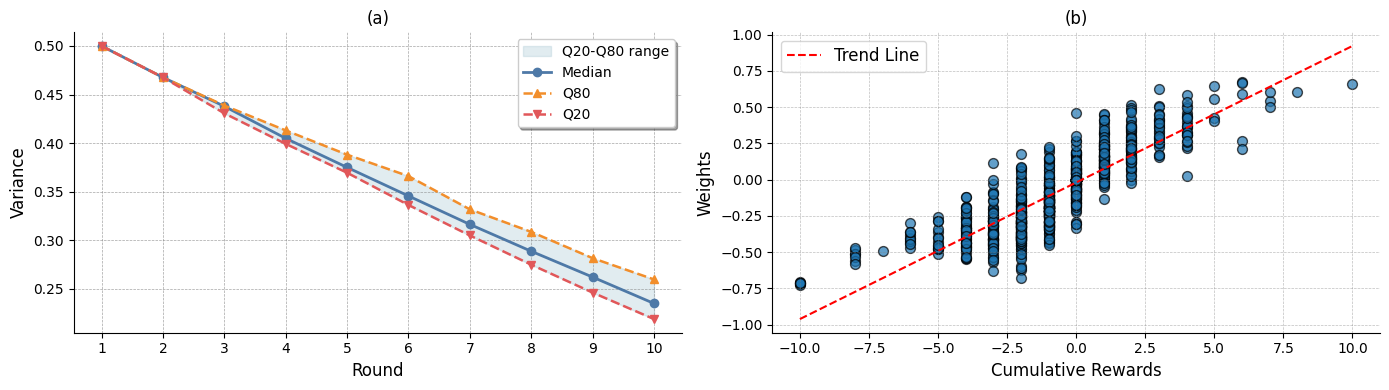

In [11]:
sigma2_evolution = np.array([
    [response["userContext"]["sigma2"]
     for response in context["responseStack"]
    ] for _, context in treatment_personalization_context.items()])

total_variances_by_user = np.power(np.prod(sigma2_evolution, axis=2), 1/sigma2_evolution.shape[2])[:,::-1]

# Define the data and quantiles
# Plot setup
plt.figure(figsize=(14, 4))
plt.subplot(1,2,1)
x = range(1, 11)
plt.title("(a)")
median = np.quantile(total_variances_by_user[:, [k for k in range(11) if k != 4]], 0.5, axis=0)
q80 = np.quantile(total_variances_by_user[:, [k for k in range(11) if k != 4]], 0.8, axis=0)
q20 = np.quantile(total_variances_by_user[:, [k for k in range(11) if k != 4]], 0.2, axis=0)

# Colors: Muted blues and grays for a professional look
median_color = '#4E79A7'    # Muted blue
q80_color = '#F28E2B'       # Muted orange
q20_color = '#E15759'       # Muted red
fill_color = '#9EC1CF'      # Light blue for fill



# Shaded area between Q20 and Q80
plt.fill_between(x, q20, q80, color=fill_color, alpha=0.3, label="Q20-Q80 range")

# Plot lines with markers
plt.plot(x, median, color=median_color, linewidth=2, marker='o', markersize=6, linestyle='-', label="Median")
plt.plot(x, q80, color=q80_color, linewidth=1.8, marker='^', markersize=6, linestyle='--', label="Q80")
plt.plot(x, q20, color=q20_color, linewidth=1.8, marker='v', markersize=6, linestyle='--', label="Q20")

# Title and labels with adjusted font size
plt.xlabel("Round", fontsize=12)
plt.ylabel("Variance", fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Customize ticks and grid
plt.xticks(x, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)

# Legend with enhanced styling
plt.legend(fontsize=10, loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.subplot(1,2,2)

rewards_by_level = np.array([
    [int(request["reward"]) * np.array(response["encoding"]) 
     for request, response in zip(val["requestStack"], val["responseStack"][1:])] 
     for key, val in {
         **treatment_personalization_context, 
         #**control_personalization_context
     }.items()])

mu_evolution = np.array([
    [response["userContext"]["mu"]
     for response in personalization_context["responseStack"]
    ] for _, personalization_context in treatment_personalization_context.items() 
])


plt.scatter(
    rewards_by_level.sum(axis=1).reshape(-1),       # X values: Cumulative Rewards
    mu_evolution[:, 0, :].reshape(-1),              # Y values: Learned Reward Model Weight
    alpha=0.7,                                      # Transparency for overlapping points
    edgecolor='k',                                  # Black edge color for each point
    color="#1f77b4",                                # Main color for points (a professional blue)
    s=50                                            # Size of points
)

# Labels and title
plt.xlabel("Cumulative Rewards", fontsize=12)
plt.ylabel("Weights", fontsize=12)
plt.title("(b)")

# Add grid and style it subtly
plt.grid(visible=True, which='both', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Remove top and right spines for a cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add a trendline for better insights, if relevant
z = np.polyfit(rewards_by_level.sum(axis=1).reshape(-1), mu_evolution[:, 0, :].reshape(-1), 1)
p = np.poly1d(z)
plt.plot(np.linspace(-10,10), p(np.linspace(-10,10)), color="red", linewidth=1.5, linestyle="--", label="Trend Line")

# Add a legend (optional, here for the trendline)
plt.legend(loc="best", fontsize=12)

plt.tight_layout()  # Adjusts plot to fit all elements neatly
plt.savefig("paper_plot_reward_model_convergence.svg", bbox_inches="tight")

(60, 10, 15)


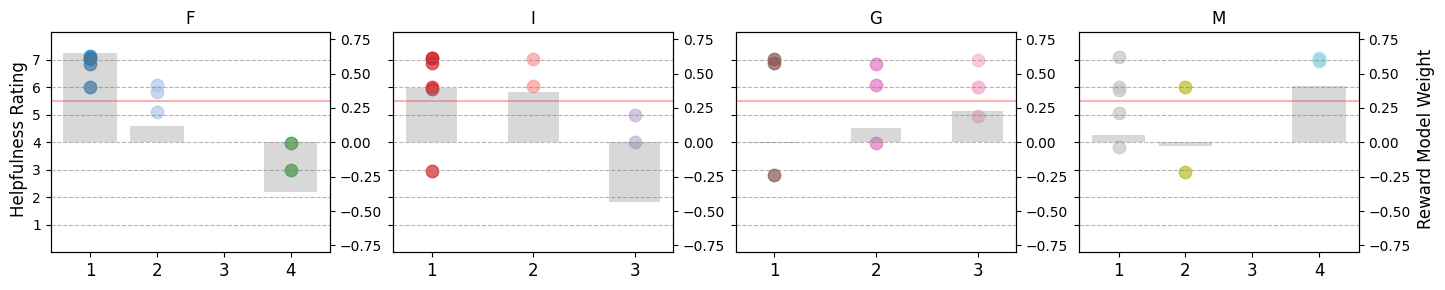

In [21]:
rating_by_hyperparameter_level = np.array([
    [int(request["userInput"]) * np.array(response["encoding"])
     for request, response in zip(personalization_context["requestStack"], personalization_context["responseStack"][1:])
    ] for _, personalization_context in treatment_personalization_context.items()
])

mu_evolution = np.array([
    [response["userContext"]["mu"]
     for response in personalization_context["responseStack"]
    ] for _, personalization_context in treatment_personalization_context.items() 
])


for user_index in [12]:
    print(rating_by_hyperparameter_level.shape)
    rating_data = rating_by_hyperparameter_level[user_index,:,:]
    mu_data = mu_evolution[user_index,0,:]
    positions = [3, 0, 2, 1, 4, 5, 6, 7, 8, 9, 14, 12, 13, 11]
    mu_data_reshuffled = mu_data[positions]
    rating_data_reshuffled = rating_data[:, positions]

    hyperparameterLevels = {
        "exclude": [
          "[]",
          "[\"num__weekday\"]",
          "[\"num__windspeed\"]",
          "[\"num__windspeed\", \"num__weekday\"]",
        ],
        "interactions": [
          "1",
          "2",
          "3"
        ],
        "max_bins": [
          "8",
          "16",
          "256"
        ],
        "monotonicity_constraints": [
          "[]",
          "[\"num__atemp\"]",
          "[\"num__windspeed\"]",  
          "[\"num__atemp\", \"num__windspeed\"]",
        ]
    }

    num_columns = 14 #encoding_evolution["Treatment"].shape[1]
    colors = plt.cm.tab20(np.linspace(0, 1, num_columns))  # Choose a distinct color for each column

    # Create subplots with one row and as many columns as parameters
    fig, axes = plt.subplots(1, len(hyperparameterLevels), figsize=(14, 3), sharey=True)

    #fig.suptitle(f"user {user_id}", fontsize=16)

    # Loop through hyperparameter levels to plot each subplot
    for i, (parameter_name, levels) in enumerate(hyperparameterLevels.items()):

        offset = sum([len(hyperparameterLevels[hp]) for hp in list(hyperparameterLevels.keys())[:i]])
        ax = axes[i]  # Current subplot axis

        for j, col in enumerate(range(offset, offset + len(levels))):
            # Get the non-zero ratings and corresponding row indices (time steps) for this column
            row_indices = np.nonzero(rating_data_reshuffled[:, col])[0]
            ratings = rating_data_reshuffled[row_indices, col] + np.random.normal(0, 0.08, size=row_indices.shape)

            # Plot each column's points with a distinct color
            ax.scatter([j] * len(ratings), ratings, color=colors[col], s=80, alpha=0.7)

        # Set labels and title for each subplot
        alphabet = "FIGM"
        ax.set_title(f"{alphabet[i]}", fontsize=12)
        ax.set_ylim(0, 8)
        ax.set_yticks(range(1,8))
    
        ax.grid(axis="y", linestyle="--", color="gray", alpha=0.6)
        ax.axhline(5.5, color="red", alpha=0.3)

        # Set custom x-tick labels for each column
        ax.set_xticks(range(len(levels)))
        ax.set_xticklabels([f"{k+1}" for k in range(len(levels))], fontsize=12)
        # Add a second y-axis for the secondary quantity (bar plot)
        ax_secondary = ax.twinx()
        bar_width = 0.3 * len(levels) - 0.4
        ax_secondary.bar(range(len(levels)), mu_data_reshuffled[offset:offset+len(levels)], color="gray", alpha=0.3, width=bar_width, label="Secondary Quantity")

        # Set secondary y-axis label
        ax_secondary.set_ylim(-0.8, 0.8)

    # Global y-axis label
    fig.text(-0.005, 0.52, 'Helpfulness Rating', va='center', rotation='vertical', fontsize=12)
    fig.text(1, 0.52, 'Reward Model Weight', va='center', rotation='vertical', fontsize=12)
    plt.tight_layout()
    #plt.show()
    plt.savefig(f"paper_plot_individual_personalization_result.svg", bbox_inches="tight")

/tmp/ipykernel_554631/3392955005.py:13: RuntimeWarning: divide by zero encountered in log2
  -(q1 * np.log2(q1) + (1 - q1) * np.log2(1 - q1))
/tmp/ipykernel_554631/3392955005.py:13: RuntimeWarning: invalid value encountered in multiply
  -(q1 * np.log2(q1) + (1 - q1) * np.log2(1 - q1))
/tmp/ipykernel_554631/3392955005.py:13: RuntimeWarning: invalid value encountered in scalar multiply
  -(q1 * np.log2(q1) + (1 - q1) * np.log2(1 - q1))


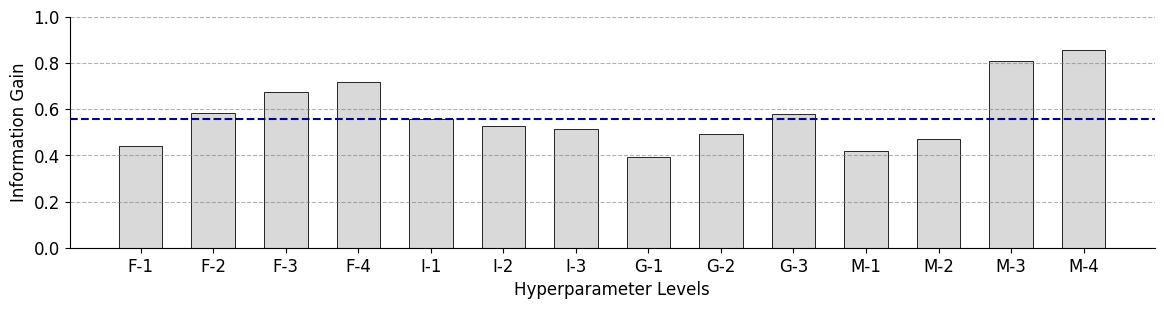

In [19]:
def entropy(arr: np.ndarray, axis: int) -> np.ndarray:
    # Count the number of 1s and non-zero entries along the specified axis
    n_p1 = (arr == 1).sum(axis=axis)
    n_total = (arr != 0).sum(axis=axis)
    
    # Calculate q1, setting to NaN when n_total is zero
    q1 = np.where(n_total != 0, n_p1 / n_total, np.nan)
    
    # Compute entropy with additional handling for q1 = 0 or q1 = 1
    entropy = np.where(
        (q1 == 0) | (q1 == 1) | np.isnan(q1), 
        0,  # Entropy is 0 when q1 is 0, 1, or undefined
        -(q1 * np.log2(q1) + (1 - q1) * np.log2(1 - q1))
    )
    
    return entropy


abbreviated_levels = {
    'exclude: ["num__weekday"]': "F-2",
    'exclude: ["num__windspeed", "num__weekday"]': "F-4",
    'exclude: ["num__windspeed"]': "F-3",
    'exclude: []': "F-1",
    'interactions: 1': "I-1",
    'interactions: 2': "I-2",
    'interactions: 3': "I-3",
    'max_bins: 8': "G-1",
    'max_bins: 16': "G-2",
    'max_bins: 256': "G-3",
    'min_samples_leaf: 64': "D-1",
    'monotonicity_constraints: ["num__atemp", "num__windspeed"]': "M-4",
    'monotonicity_constraints: ["num__atemp"]': "M-2",
    'monotonicity_constraints: ["num__windspeed"]': "M-3",
    'monotonicity_constraints: []': "M-1",
}

hyperparameterLevels = {
    "exclude": [
      "[\"num__weekday\"]",
      "[\"num__windspeed\", \"num__weekday\"]",
      "[\"num__windspeed\"]",
      "[]"
    ],
    "interactions": [
      "1",
      "2",
      "3"
    ],
    "max_bins": [
      "8",
      "16",
      "256"
    ],
    "min_samples_leaf": [
      "64"
    ],
    "monotonicity_constraints": [
      "[\"num__atemp\", \"num__windspeed\"]",
      "[\"num__atemp\"]",
      "[\"num__windspeed\"]",
      "[]"
    ]
}

hyperparameterLevelList = [f"{name}: {level}" for name,levels in hyperparameterLevels.items() for level in levels]


rewards_by_level = np.array([
    [int(request["reward"]) * np.array(response["encoding"]) 
     for request, response in zip(val["requestStack"], val["responseStack"][1:])] 
     for key, val in {
         **treatment_personalization_context, 
         #**control_personalization_context
     }.items()])
   


n_users, n_rounds, n_hparams = rewards_by_level.shape
nonzero_ratings = {
    hyperparameterLevelList[i]: [
        l for j in range(n_users) if len(l:=[reward for reward in rewards_by_level[j,:,i] if reward != 0]) > 0] 
    for i in range(n_hparams)
}

entropy_data = {
    key: 1- np.array([entropy(np.array(v), axis=0) for v in val]) for key, val in nonzero_ratings.items() if key != 'min_samples_leaf: 64'
}


data = list(entropy_data.values())
positions = [3, 0, 2, 1, 4, 5, 6, 7, 8, 9, 13, 11, 12, 10]
labels = [abbreviated_levels[level] for level in entropy_data.keys()]


fig, ax = plt.subplots(figsize=(14,3))

x = [labels[p] for p in positions]
y1 = [np.mean(data[p]) for p in positions]

ax.bar(x, y1, color="lightgray", edgecolor="black", linewidth=0.7, alpha=0.85, width=0.6)
ax.axhline(np.mean([d for p in positions for d in data[p]]), color="darkblue", linestyle="--")

# Add a horizontal grid with a light style
ax.grid(axis="y", linestyle="--", color="gray", alpha=0.6)

# Remove top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Tweak tick parameters for style
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(x)
ax.set_ylim(0,1)

vcolors = (
    4 * ["#B8C5D1"] +   # Light Slate Blue (slightly brighter for contrast)
    3 * ["#5E7E97"] +   # Medium Dusty Blue (a bit richer in tone)
    3 * ["#355670"] +   # Deep Slate Blue (providing more contrast)
    #["#1F3A4D"] +       # Charcoal Blue (dark and grounding)
    4 * ["#486F8A"]     # Steel Blue (a bit more saturated for vibrancy)
)



#for patch, color in zip(bplot['boxes'], vcolors):
#    patch.set_facecolor(color)

ax.set_xlabel("Hyperparameter Levels", fontsize=12)
ax.set_ylabel("Information Gain", fontsize=12)
#ax.set_title("Mean Information Gain", fontsize=14, fontweight="bold")
plt.savefig("paper_plot_mean_information_gain.svg")

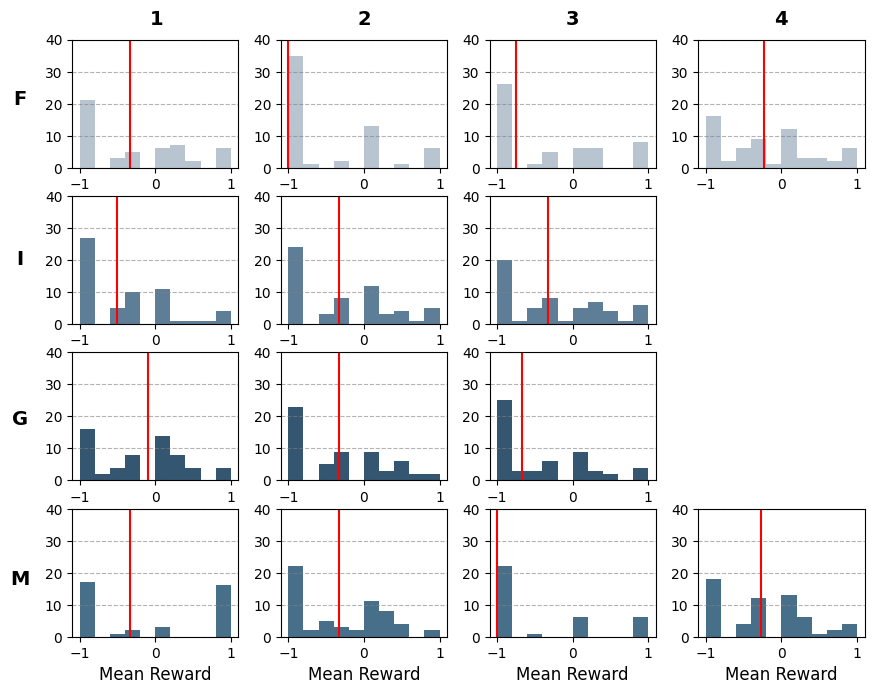

In [18]:
mean_data = {
    key: np.array([np.mean(np.array(v), axis=0) for v in val]) for key, val in nonzero_ratings.items()
}

abbreviated_levels = {
    'exclude: ["num__weekday"]': "A-1",
    'exclude: ["num__windspeed", "num__weekday"]': "A-2",
    'exclude: ["num__windspeed"]': "A-3",
    'exclude: []': "A-4",
    'interactions: 1': "B-1",
    'interactions: 2': "B-2",
    'interactions: 3': "B-3",
    'max_bins: 8': "C-1",
    'max_bins: 16': "C-2",
    'max_bins: 256': "C-3",
    'min_samples_leaf: 64': "D-1",
    'monotonicity_constraints: ["num__atemp", "num__windspeed"]': "D-1",
    'monotonicity_constraints: ["num__atemp"]': "D-2",
    'monotonicity_constraints: ["num__windspeed"]': "D-3",
    'monotonicity_constraints: []': "D-4",
}

abbreviated_levels_reversed = {val: key for key, val in abbreviated_levels.items()}


plt.figure(figsize=(10, 8))
for i, key in enumerate(["A-1", "A-2", "A-3", "A-4"]):
    ax = plt.subplot(4, 4, i + 1)
    plt.hist(mean_data[abbreviated_levels_reversed[key]], color="#B8C5D1")
    plt.axvline(np.median(mean_data[abbreviated_levels_reversed[key]]), color="red")
    plt.grid(axis="y", linestyle="--", color="gray", alpha=0.6)
    plt.ylim(0, 40)
    if i % 4 != 0:  # Only show Y-axis label on the first column
        ax.set_ylabel('')

for i, key in enumerate(["B-1", "B-2", "B-3"]):
    ax = plt.subplot(4, 4, 4 + i + 1)
    plt.hist(mean_data[abbreviated_levels_reversed[key]], color="#5E7E97")
    plt.axvline(np.median(mean_data[abbreviated_levels_reversed[key]]), color="red")
    plt.grid(axis="y", linestyle="--", color="gray", alpha=0.6)
    plt.ylim(0, 40)
    if i % 4 != 0:  # Only show Y-axis label on the first column
        ax.set_ylabel('')

for i, key in enumerate(["C-1", "C-2", "C-3"]):
    ax = plt.subplot(4, 4, 8 + i + 1)
    plt.hist(mean_data[abbreviated_levels_reversed[key]], color="#355670")
    plt.axvline(np.median(mean_data[abbreviated_levels_reversed[key]]), color="red")
    plt.grid(axis="y", linestyle="--", color="gray", alpha=0.6)
    plt.ylim(0, 40)
    if i % 4 != 0:  # Only show Y-axis label on the first column
        ax.set_ylabel('')

for i, key in enumerate(["D-1", "D-2", "D-3", "D-4"]):
    ax = plt.subplot(4, 4, 12 + i + 1)
    plt.hist(mean_data[abbreviated_levels_reversed[key]], color="#486F8A")
    plt.axvline(np.median(mean_data[abbreviated_levels_reversed[key]]), color="red", label="Median")
    plt.grid(axis="y", linestyle="--", color="gray", alpha=0.6)
    plt.ylim(0, 40)
    plt.xlabel("Mean Reward", fontsize=12)  # Only bottom row needs X-axis labels
    if i % 4 != 0:  # Only show Y-axis label on the first column
        ax.set_ylabel('')

for row, label in enumerate(["F", "I", "G", "M"]):
    plt.gcf().text(0.09, 0.8 - row * 0.2, label, ha='center', va='center', fontsize=14, rotation='horizontal', fontweight="bold")

# Add column labels at the top of each column
for col, label in enumerate([1,2,3,4]):
    plt.gcf().text(0.227 + col * 0.208, 0.9, label, ha='center', va='center', fontsize=14, fontweight="bold")

plt.tight_layout(rect=[0.1, 0.05, 0.95, 0.9])  # Adjust layout to make room for labels
plt.subplots_adjust(hspace=0.22)
plt.savefig("paper_plot_mean_reward_distribution.svg")